In [34]:
import torch

print(torch.backends.mps.is_available())

True


In [35]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [36]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping


In [37]:
import pandas as pd

df = pd.read_csv('/Users/charlotecalosor/Downloads/SEMI-CLEANED(without Rating)_dataset.csv')

In [38]:
df

,Category,Label,Review
0,Home_and_Kitchen_5,1,"Love this! Well made, sturdy, and very comfort..."
1,Home_and_Kitchen_5,1,"love it, a great upgrade from the original. I'..."
2,Home_and_Kitchen_5,1,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,1,Very nice set. Good quality. We have had the s...
...,...,...,...
40400,Clothing_Shoes_and_Jewelry_5,0,I had read some reviews saying that this bra r...
40401,Clothing_Shoes_and_Jewelry_5,1,I wasn't sure exactly what it would be. It is ...
40402,Clothing_Shoes_and_Jewelry_5,0,"You can wear the hood by itself, wear it with ..."
40403,Clothing_Shoes_and_Jewelry_5,1,I liked nothing about this dress. The only rea...


In [39]:
df.tail()

,Category,Label,Review
40400,Clothing_Shoes_and_Jewelry_5,0,I had read some reviews saying that this bra r...
40401,Clothing_Shoes_and_Jewelry_5,1,I wasn't sure exactly what it would be. It is ...
40402,Clothing_Shoes_and_Jewelry_5,0,"You can wear the hood by itself, wear it with ..."
40403,Clothing_Shoes_and_Jewelry_5,1,I liked nothing about this dress. The only rea...
40404,Clothing_Shoes_and_Jewelry_5,0,I work in the wedding industry and have to wor...


In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Label'])
print("Classes:", le.classes_)

Classes: [0 1]


In [41]:
NUM_WORDS = 10000
MAX_LEN   = 100

tokenizer = Tokenizer(num_words=NUM_WORDS)
tokenizer.fit_on_texts(df['Review'])

X = tokenizer.texts_to_sequences(df['Review'])
X = pad_sequences(X, maxlen=MAX_LEN)
print("Text shape:", X.shape)

Text shape: (40405, 100)


In [42]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")

Train: 32324 | Val: 4040 | Test: 4041


In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.regularizers import l2

model = Sequential([
    Embedding(input_dim=NUM_WORDS + 1, output_dim=64),
    Conv1D(32, 5, activation='relu', kernel_regularizer=l2(0.01)),
    GlobalMaxPooling1D(),
    Dropout(0.6),
    Dense(16, activation='relu', kernel_regularizer=l2(0.02)),
    Dropout(0.6),
    Dense(1, activation='sigmoid')
])


In [44]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [45]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

In [46]:
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [47]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5687 - loss: 0.9379 - val_accuracy: 0.7839 - val_loss: 0.7134
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7358 - loss: 0.6242 - val_accuracy: 0.8589 - val_loss: 0.4850
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8265 - loss: 0.5071 - val_accuracy: 0.8854 - val_loss: 0.4057
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8577 - loss: 0.4460 - val_accuracy: 0.8916 - val_loss: 0.3665
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8776 - loss: 0.4077 - val_accuracy: 0.8988 - val_loss: 0.3451
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8908 - loss: 0.3756 - val_accuracy: 0.9012 - val_loss: 0.3295
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8981 - loss: 0.3565 - val_accuracy: 0.9047 - val_loss: 0.3197
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9051 - loss: 0.3369 - val_accuracy: 0.

In [48]:
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      2022
           1       0.91      0.90      0.90      2019

    accuracy                           0.90      4041
   macro avg       0.90      0.90      0.90      4041
weighted avg       0.90      0.90      0.90      4041



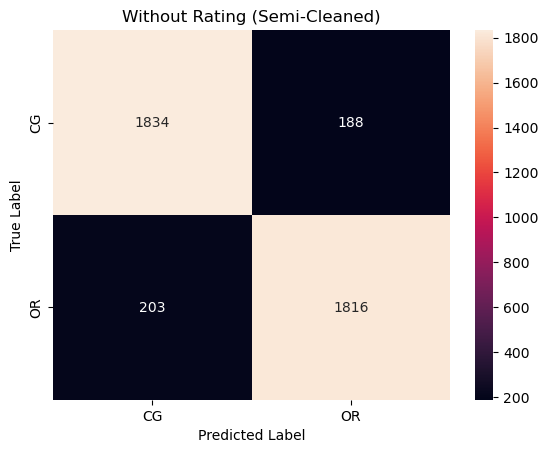

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["OR", "CG"]  # adjust if your encoding is reversed

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['CG', 'OR'], yticklabels=['CG', 'OR'])
plt.title("Without Rating (Semi-Cleaned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

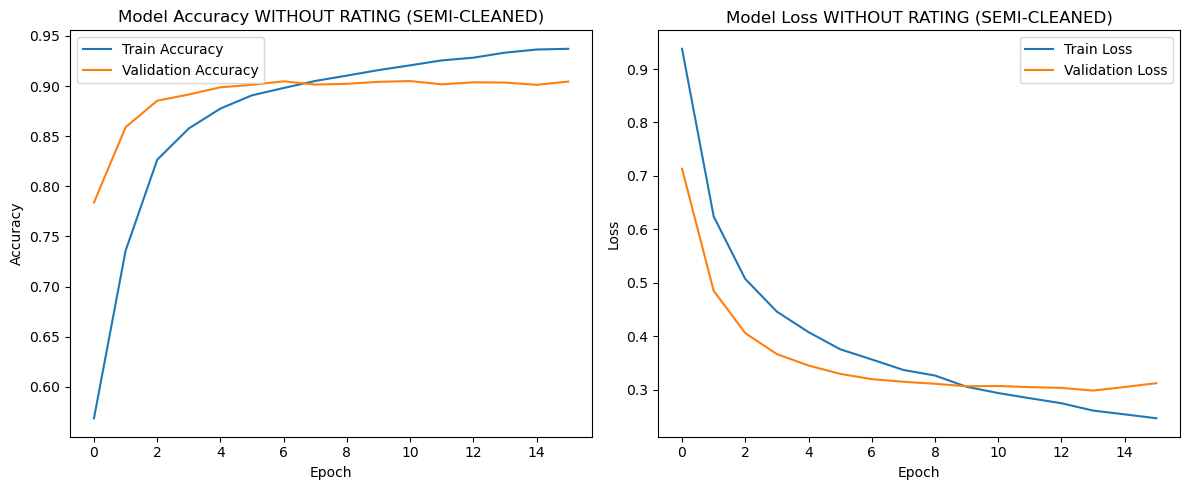

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy subplot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy WITHOUT RATING (SEMI-CLEANED)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss subplot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss WITHOUT RATING (SEMI-CLEANED)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [51]:
# Check what max length your model expects
print(model.input_shape)

(None, 100)


In [52]:
print(len(tokenizer.word_index))

48729


In [53]:
test_text = ["This product is absolutely amazing!"]
seq = tokenizer.texts_to_sequences(test_text)
print("Sequence:", seq)

Sequence: [[8, 83, 7, 377, 340]]


In [54]:
test_text = ["This product is absolutely amazing!"]
seq = tokenizer.texts_to_sequences(test_text)
padded = pad_sequences(seq, maxlen=model.input_shape[1])

print("Word index size:", len(tokenizer.word_index))
print("Sequence:", seq)
print("Padded shape:", padded.shape)
print("Padded values:", padded)

pred = model.predict(padded, verbose=0)
print("Raw prediction:", pred)

Word index size: 48729
Sequence: [[8, 83, 7, 377, 340]]
Padded shape: (1, 100)
Padded values: [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   8  83   7 377 340]]
Raw prediction: [[0.43142653]]


In [55]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

while True:
    # Ask for input
    new_text = input("\nEnter a review: ")

    # Exit condition
    if new_text.lower() == 'exit':
        print("Program ended.")
        break

    # Preprocess
    new_seq = tokenizer.texts_to_sequences([new_text])
    new_padded = pad_sequences(new_seq, maxlen=model.input_shape[1])

    # Predict
    prediction = model.predict(new_padded, verbose=0)

    # Output label
    if prediction[0][0] > 0.5:
        print(f"Prediction: CG (Computer Generated) — confidence: {prediction[0][0]:.2%}")
    else:
        print(f"Prediction: OR (Original Review) — confidence: {1 - prediction[0][0]:.2%}")


Enter a review:  The product is highly efficient and offers great value for the price. I am very satisfied with the overall quality and performance. 


Prediction: CG (Computer Generated) — confidence: 55.63%



Enter a review:  This item arrived in excellent condition, the packaging was secure and the delivery was good.  


Prediction: CG (Computer Generated) — confidence: 50.91%



Enter a review:  This device is easy to operate it meets the specifications in the product description.


...

Prediction: OR (Original Review) — confidence: 94.97%



Enter a review:  This is my purchase of the month. Thanks seller


Prediction: OR (Original Review) — confidence: 91.09%



Enter a review:  exit


Program ended.
